In [5]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/nsls2/data/lix/proposals/2025-2/pass-317792/dev/mani/ganrec_updated/ganrec')
from ganrectf.utils import angles, nor_tomo
from ganrectf.ganrec import GANtomo

from ganrectf.propagators import TomoRadon

import tensorflow as tf

In [6]:
raw_data = np.load('./test_data/SheppLogan_easy.npy')
angs = np.linspace(0,180, 90)

angs_tf = tf.cast(np.deg2rad(angs), dtype = tf.float32)
gtrecon_tf = tf.cast(raw_data[None, ..., None], dtype = tf.float32)

radon_obj = TomoRadon(gtrecon_tf, angs_tf)
sino_gt_tf =  radon_obj.compute()
sino_gt = np.array(sino_gt_tf).squeeze()


prj = sino_gt
ang = np.deg2rad(angs)

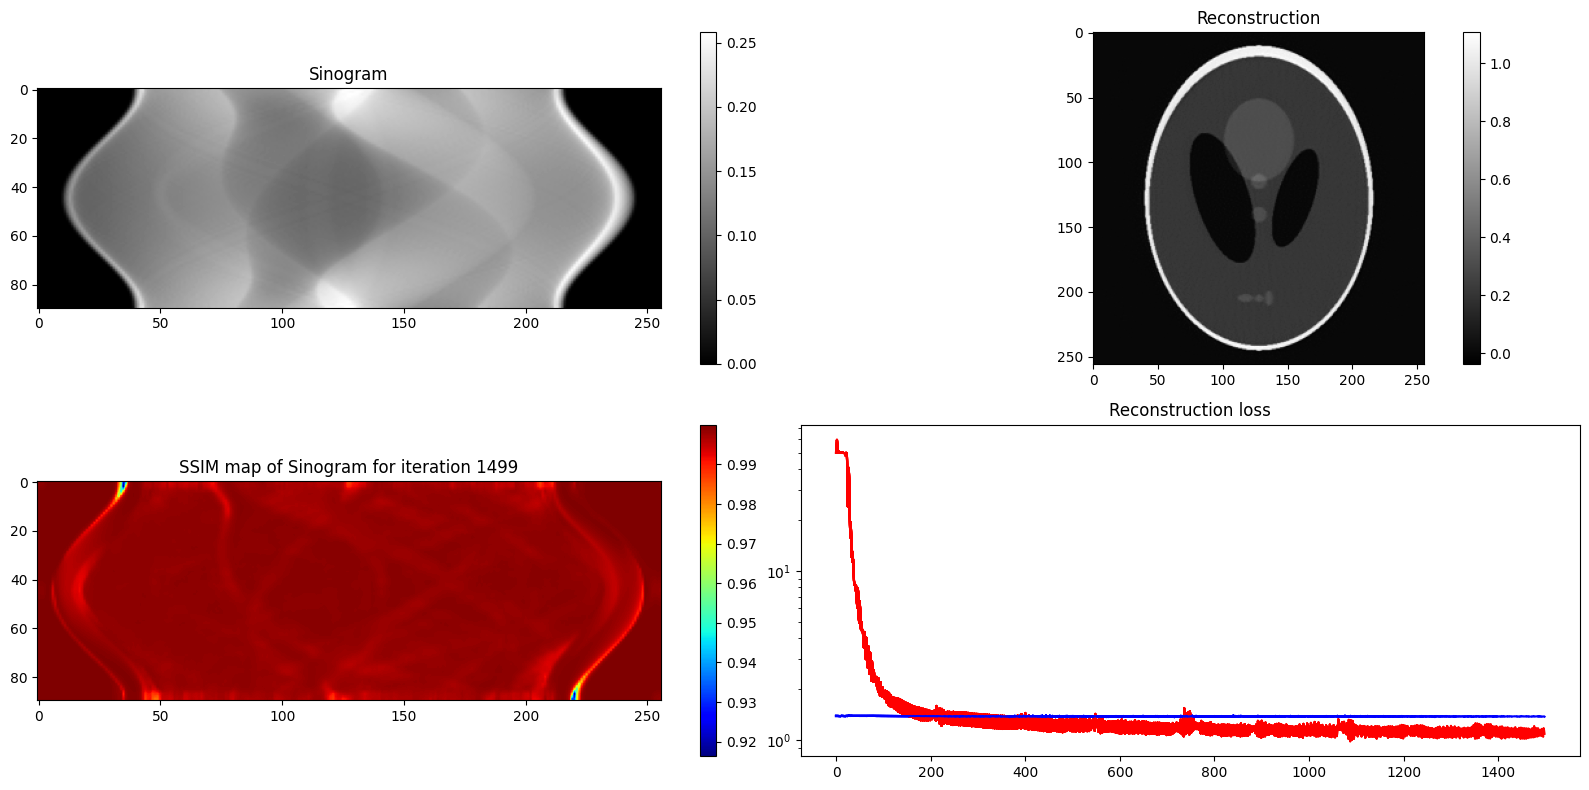

<Figure size 640x480 with 0 Axes>

Reconstruction: 100%|██████████| 1500/1500 [00:32<00:00, 45.92it/s, D_loss=1.3714, G_loss=1.1111]


In [7]:
rec = GANtomo(prj, ang, iter_num=1500, recon_monitor=True).recon()
# rec = engine.recon(prj)

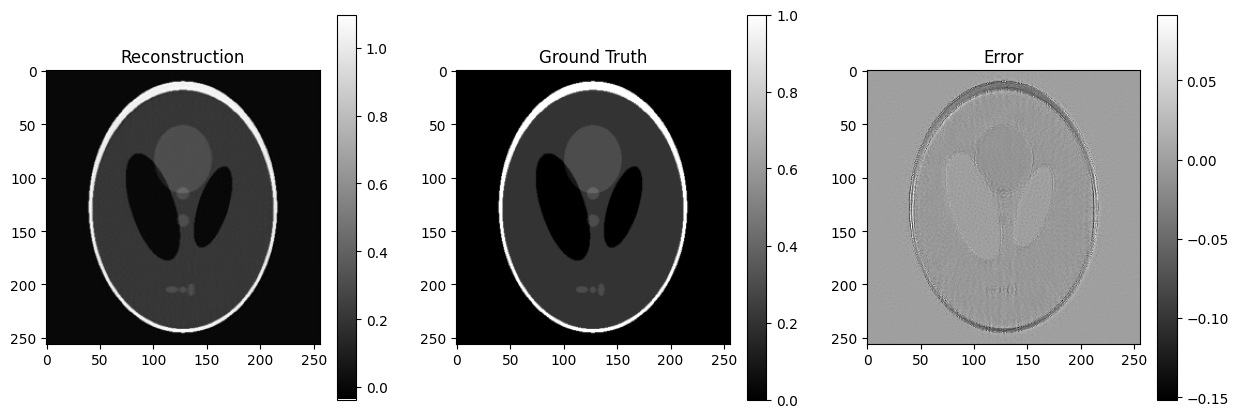

In [8]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

im0 = ax[0].imshow(rec, cmap = 'gray')
ax[0].set_title('Reconstruction')
cbar0 = fig.colorbar(im0, ax = ax[0])

im1 = ax[1].imshow(raw_data, cmap = 'gray')
ax[1].set_title('Ground Truth')
cbar1 = fig.colorbar(im1, ax = ax[1])

im2 = ax[2].imshow(raw_data - rec, cmap = 'gray')
ax[2].set_title('Error')
cbar2 = fig.colorbar(im2, ax = ax[2])